# Recurrent Neural Network Modeling - Complexity Metric Input

In [1]:
# importing the sys module
import sys		 

# appending the directory of mod.py 
# in the sys.path list
sys.path.append("C:\\Users\\gfman\\Documents\\GitHub\\bachelor-thesis")	 

from data_creator import load_3D_cm

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


In [2]:
X, y = load_3D_cm()

# train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 4)

In [4]:
from keras.models import Sequential
from keras.layers import LSTM, Dense

# initialize RNN
model = Sequential()
model.add(LSTM(units=50, return_sequences= True, input_shape=(180,6)))
model.add(LSTM(units=50))
model.add(Dense(units = 2**5))
model.add(Dense(units = 2**2))
model.add(Dense(units=1, activation = 'sigmoid'))

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics = ["accuracy"])

# Train the model
model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/10


c:\Users\gfman\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


35/35 ━━━━━━━━━━━━━━━━━━━━ 7s 109ms/step - accuracy: 0.8476 - loss: 0.4313 - val_accuracy: 0.9153 - val_loss: 0.2725
Epoch 2/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 102ms/step - accuracy: 0.8792 - loss: 0.3294 - val_accuracy: 0.9098 - val_loss: 0.2461
Epoch 3/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 104ms/step - accuracy: 0.8908 - loss: 0.2895 - val_accuracy: 0.9071 - val_loss: 0.2397
Epoch 4/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 116ms/step - accuracy: 0.8910 - loss: 0.2800 - val_accuracy: 0.8907 - val_loss: 0.2718
Epoch 5/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 106ms/step - accuracy: 0.9079 - loss: 0.2581 - val_accuracy: 0.9153 - val_loss: 0.2215
Epoch 6/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 89ms/step - accuracy: 0.9015 - loss: 0.2376 - val_accuracy: 0.9208 - val_loss: 0.2358
Epoch 7/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 110ms/step - accuracy: 0.8985 - loss: 0.2670 - val_accuracy: 0.9208 - val_loss: 0.2231
Epoch 8/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 110ms/step - accuracy: 0.9103 - loss: 0.2392 - val_accuracy: 0.9098 - val_l

## Results

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step
Testing ROC AUC 0.6092001092001091


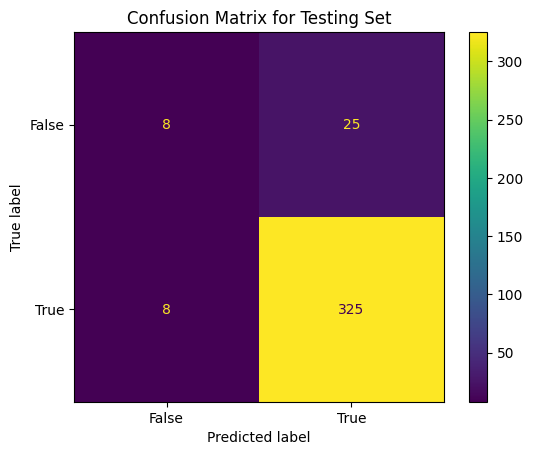

In [5]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, ConfusionMatrixDisplay
preds_rnn = model.predict(X_test)
print("Testing ROC AUC", roc_auc_score(y_test, preds_rnn>0.5))
cm1 = ConfusionMatrixDisplay.from_predictions(y_test, preds_rnn>0.5)
cm1.ax_.set_title("Confusion Matrix for Testing Set")
plt.show()